# 01 · Exploración y Limpieza del Corpus

**Proyecto 3 — Chatbot Turístico con RAG + Fine-Tuning**
**Curso:** Minería de Textos — CUC

Corpus de reseñas turísticas de Costa Rica (Proyectos 1 y 2). Se limpia y se explora con las
herramientas estándar de pandas antes de pasarlo al pipeline RAG (notebook `02`).


## 1. Carga de datos

In [1]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("corpus_unificado.csv")
df.shape


(5018, 7)

In [2]:
df.head()


,texto,calificacion,tipo_lugar,fuente,fecha,lugar,polaridad
0,"Tour fabuloso, bellísimo el bosque nuboso de M...",5.0,parque,civitatis,12/28/2020,Excursión a los puentes colgantes de Monteverde,positiva
1,Vale la pena ir a ver los puentes colgantes de...,4.0,parque,civitatis,08/08/2021,Excursión a los puentes colgantes de Monteverde,positiva
2,"La actividad es muy bonita, sin embargo hay do...",4.0,parque,civitatis,09/15/2022,Excursión a los puentes colgantes de Monteverde,positiva
3,No fui a este tour sino al del.volcan poas 100...,5.0,parque,civitatis,10/29/2025,Excursión a los puentes colgantes de Monteverde,positiva
4,"Muy interesante todo el recorrido, con la visi...",4.0,parque,civitatis,01/13/2024,Excursión al volcán Arenal + Aguas termales,positiva


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5018 entries, 0 to 5017
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   texto         5018 non-null   object 
 1   calificacion  5018 non-null   float64
 2   tipo_lugar    5018 non-null   object 
 3   fuente        5018 non-null   object 
 4   fecha         5018 non-null   object 
 5   lugar         5018 non-null   object 
 6   polaridad     5018 non-null   object 
dtypes: float64(1), object(6)
memory usage: 274.6+ KB


In [4]:
df.describe(include="all")


,texto,calificacion,tipo_lugar,fuente,fecha,lugar,polaridad
count,5018,5018.000000,5018,5018,5018,5018,5018
unique,5018,NaN,7,2,309,212,3
top,Sky Adventures La Fortuna es grandioso. Las ac...,NaN,parque,google_maps,Hace un año,Hotel Las Brumas,positiva
freq,1,NaN,1724,4746,674,48,4404
mean,NaN,4.494420,NaN,NaN,NaN,NaN,NaN
std,NaN,0.989112,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,4.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,5.000000,NaN,NaN,NaN,NaN,NaN


## 2. Calidad de los datos

Nulos, duplicados y consistencia entre `calificacion` y `polaridad`, todo con métodos de pandas.

In [5]:
df.isnull().sum()


texto           0
calificacion    0
tipo_lugar      0
fuente          0
fecha           0
lugar           0
polaridad       0
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
# clave normalizada (minusculas, sin tildes, sin espacios extra) para detectar
# duplicados "casi exactos" que difieren solo en mayusculas/espacios/tildes
clave = (
    df["texto"].str.lower()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df.duplicated(subset=None).sum(), clave.duplicated().sum()


(np.int64(0), np.int64(0))

In [8]:
calificacion_vs_polaridad = pd.crosstab(df["calificacion"], df["polaridad"])
calificacion_vs_polaridad


polaridad,negativa,neutral,positiva
calificacion,,,
1.0,193,0,0
2.0,124,0,0
3.0,0,297,0
4.0,0,0,799
5.0,0,0,3605


## 3. Limpieza

Todo vectorizado con `.str`, sin recorrer el DataFrame fila por fila.

In [9]:
EMOJI_PATTERN = r"[\U0001F1E6-\U0001FAFF\U00002600-\U000027BF\U00002B00-\U00002BFF\U0000FE0F\U0000200D]+"

df["texto"] = (
    df["texto"]
    .str.replace(EMOJI_PATTERN, "", regex=True)   # emojis
    .str.replace(r"[\r\n\t]+", " ", regex=True)  # saltos de linea / tabs
    .str.replace(r" {2,}", " ", regex=True)        # espacios dobles
    .str.strip()
)

df["clave_normalizada"] = (
    df["texto"].str.lower()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
)

df["n_palabras"] = df["texto"].str.split().str.len()

df.shape


(5018, 9)

In [10]:
antes = len(df)

df = df[df["texto"].str.len() >= 10]                  # descarta vacios / muy cortos
df = df.drop_duplicates(subset="clave_normalizada")     # descarta duplicados

# recalcula polaridad a partir de la calificacion, de forma vectorizada
df["polaridad"] = np.select(
    [df["calificacion"] <= 2, df["calificacion"] == 3, df["calificacion"] >= 4],
    ["negativa", "neutral", "positiva"],
    default="",
)

df = df.drop(columns="clave_normalizada")

print(f"Filas antes: {antes}  ->  Filas despues: {len(df)}")


Filas antes: 5018  ->  Filas despues: 5018


In [11]:
os.makedirs("data", exist_ok=True)
df.to_csv("data/corpus_resenas.csv", index=False)
df.shape


(5018, 8)

## 4. Estadísticas básicas

In [12]:
df["tipo_lugar"].value_counts()


tipo_lugar
parque                 1724
hotel                   927
restaurante             912
museo                   543
tour_aventura           362
atraccion_turistica     338
mercado                 212
Name: count, dtype: int64

In [13]:
df["polaridad"].value_counts(normalize=True) * 100


polaridad
positiva    87.764049
negativa     6.317258
neutral      5.918693
Name: proportion, dtype: float64

In [14]:
df.groupby("tipo_lugar")["calificacion"].agg(["mean", "median", "count"])


,mean,median,count
tipo_lugar,,,
atraccion_turistica,4.470414,5.0,338
hotel,4.085221,5.0,927
mercado,4.608491,5.0,212
museo,4.699816,5.0,543
parque,4.586427,5.0,1724
restaurante,4.464912,5.0,912
tour_aventura,4.825967,5.0,362


In [15]:
df["n_palabras"].describe()


count    5018.000000
mean       45.757473
std        46.114930
min         2.000000
25%        18.000000
50%        33.000000
75%        58.000000
max       612.000000
Name: n_palabras, dtype: float64

In [16]:
df["lugar"].value_counts().head(10)


lugar
Hotel Las Brumas                                48
Hotel Courtyard de Marriott • Alajuela          48
Parque Nacional Volcán Irazú - Sector Prusia    48
La Guaria Inn & Suites                          48
Parque Metropolitano La Sabana                  48
Parque Diversiones                              48
Parque Okayama                                  48
Parque Nacional Volcán Poás                     48
Parque Central de San José                      48
Parque Nacional Braulio Carrillo                48
Name: count, dtype: int64

## 5. Gráficos

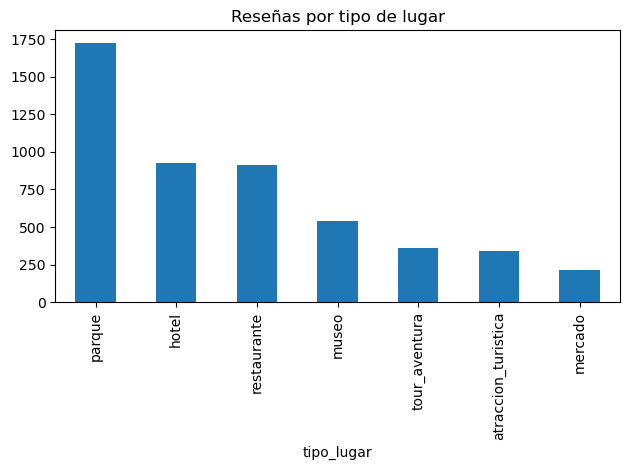

In [17]:
df["tipo_lugar"].value_counts().plot(kind="bar", title="Reseñas por tipo de lugar")
plt.tight_layout()
plt.show()


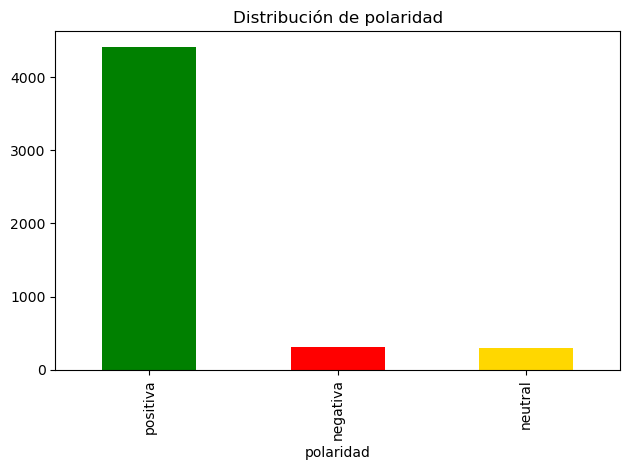

In [18]:
df["polaridad"].value_counts().plot(kind="bar", title="Distribución de polaridad", color=["green", "red", "gold"])
plt.tight_layout()
plt.show()


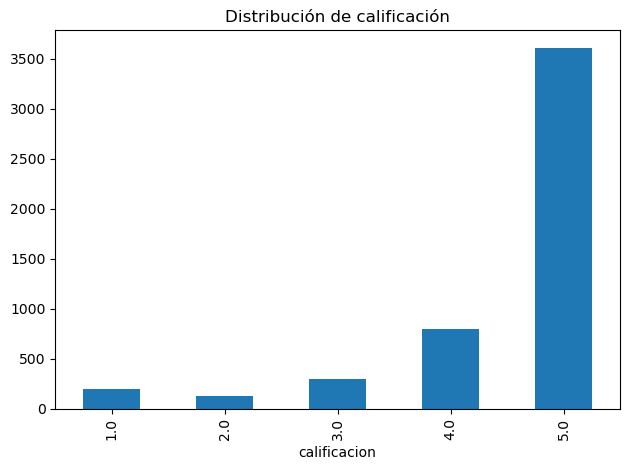

In [19]:
df["calificacion"].value_counts().sort_index().plot(kind="bar", title="Distribución de calificación")
plt.tight_layout()
plt.show()


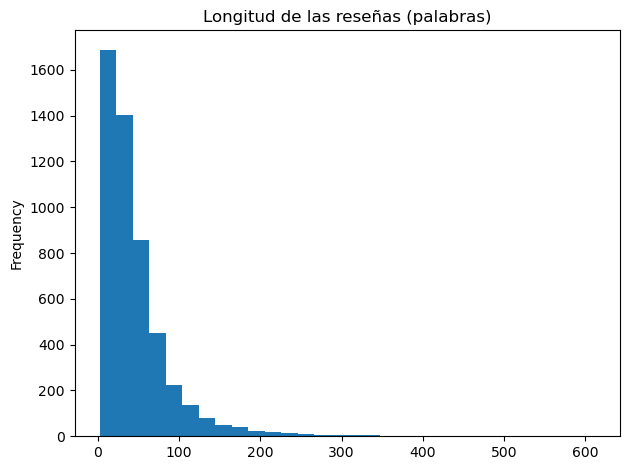

In [20]:
df["n_palabras"].plot(kind="hist", bins=30, title="Longitud de las reseñas (palabras)")
plt.tight_layout()
plt.show()


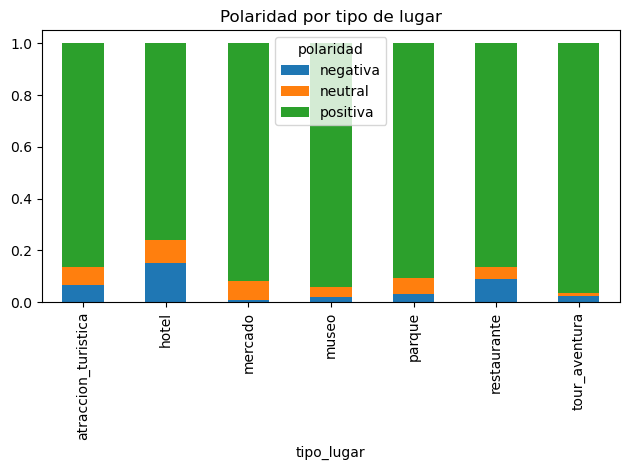

In [21]:
pd.crosstab(df["tipo_lugar"], df["polaridad"], normalize="index").plot(kind="bar", stacked=True, title="Polaridad por tipo de lugar")
plt.tight_layout()
plt.show()
